# Session 6 - Regression Analysis (Used Cars)

In this session we build linear regression models to estimate used car prices from mileage and age, then label potential bargains for the next session.


## Learning objectives

- Understand why we scope analysis to a single make/model combination.
- Fit and interpret univariate and multivariate linear regression models.
- Explain coefficients with clear units and interpret R^2, MAE, and RMSE.
- Distinguish confidence intervals for the mean from prediction intervals for new observations.
- Create an operational definition of a "bargain" from a regression baseline.


## Environment setup (installations)

Before running the notebook, install the required Python packages in the same environment as the notebook kernel.

Minimum required packages:
- `google-cloud-bigquery`
- `db-dtypes`
- `pandas`
- `matplotlib`
- `scikit-learn`
- `statsmodels`

Recommended one-liner (includes the pandas extras for BigQuery):
```bash
pip install "google-cloud-bigquery[pandas]" db-dtypes pandas matplotlib scikit-learn statsmodels pyarrow
```

If you are using the `.venv` from this repo, run:
```powershell
.\.venv\Scripts\python.exe -m pip install "google-cloud-bigquery[pandas]" db-dtypes pandas matplotlib scikit-learn statsmodels pyarrow
```

---


## Step 0 - Imports and environment checks

We set project variables, import libraries, and create output folders.


In [31]:
# Core
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# BigQuery
from google.cloud import bigquery

# Statsmodels (needed for prediction intervals)
import statsmodels.api as sm

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# BigQuery settings (align with Session 4 SQL notebook)
project_id = 'albertheadofdata101'  # Replace if your project is different
dataset_id = 'autoscout'

# Output folders (always anchored at project root)
def find_project_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / ".git").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())

DATA_RAW_DIR = PROJECT_ROOT / "data/raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data/processed"
REPORTS_DIR = PROJECT_ROOT / "docs"

for p in [DATA_RAW_DIR, DATA_PROCESSED_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101


## Step 1 - Connect to BigQuery (ADC) and quick test

We use Application Default Credentials (ADC). The quick test verifies connectivity and counts rows in the fact table.


In [32]:
# Create a BigQuery client (uses Application Default Credentials)
client = bigquery.Client(project=project_id)

# Helper: run a SQL query and return a DataFrame
def run_query(sql):
    return client.query(sql).to_dataframe()

# Quick connectivity check
sql_test = f"""
SELECT COUNT(*) AS n
FROM `{project_id}.{dataset_id}.fact_listings`
"""

print(run_query(sql_test))


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\auth\_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


       n
0  10732


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## Step 2 - Define SQL queries (top scope + modeling dataset)

We first find the most common (make, model, listing_country) combination after basic filtering. Then we pull only the columns needed for modeling.


In [33]:
sql_top_scope = f"""
SELECT
  dm.make AS make,
  dm.model AS model,
  COUNT(*) AS n_records
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
WHERE
  fl.price_eur IS NOT NULL AND fl.price_eur > 0
  AND fl.mileage_km IS NOT NULL AND fl.mileage_km > 0
  AND fl.age_years IS NOT NULL AND fl.age_years >= 0
GROUP BY make, model
ORDER BY n_records DESC
LIMIT 1
"""



In [34]:
# Pick the most common make/model scope for modeling
top_scope = run_query(sql_top_scope)

make = top_scope.loc[0, "make"]
model = top_scope.loc[0, "model"]
print(f"Scoped to: {make} / {model}")


Scoped to: audi / a3


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## Step 3 - Load data into pandas and validate

Why do we scope to one make/model?
- Prices depend strongly on make, model, and local market.
- Focusing on a single scope reduces confounding and yields a cleaner baseline.
- It keeps the regression interpretable for beginners.


In [35]:
# Build the modeling query for the selected scope
sql_modeling = f"""
SELECT
  fl.listing_id,
  fl.price_eur,
  fl.mileage_km,
  fl.age_years,
  dm.make,
  dm.model,
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
WHERE
  fl.price_eur IS NOT NULL AND fl.price_eur > 0
  AND fl.mileage_km IS NOT NULL AND fl.mileage_km > 0
  AND fl.age_years IS NOT NULL AND fl.age_years >= 0
  AND dm.make = '{make}'
  AND dm.model = '{model}'
"""

# Load data into pandas
df = run_query(sql_modeling)
print(df.head())
print('Rows:', len(df))


   listing_id  price_eur  mileage_km  age_years  make model
0         199      20480     50300.0        5.0  audi    a3
1         236      23630     14712.0        3.0  audi    a3
2         318      24950     64920.0        4.0  audi    a3
3         447      33900     25217.0        1.0  audi    a3
4         452      36900       100.0        0.0  audi    a3
Rows: 524


## Step 4 - Exploratory scatter plots (diagnostic)

We start with simple scatterplots to see whether price falls as mileage or age increases.


In [36]:
# Helper: scatter plots highlighting bargains
# We save figures to disk and also show them inline.
def plot_bargain_scatters(bargain_df, reports_dir, seed=RANDOM_SEED, max_points=20000):
    # Always keep all bargains; sample only non-bargains if needed
    is_bargain = bargain_df["bargain"] == 1
    bargains = bargain_df.loc[is_bargain]
    non_bargains = bargain_df.loc[~is_bargain]

    if len(bargain_df) <= max_points:
        plot_df = bargain_df
    else:
        keep_n = max_points - len(bargains)
        keep_n = max(0, keep_n)
        sampled_non = non_bargains.sample(n=min(keep_n, len(non_bargains)), random_state=seed)
        plot_df = pd.concat([sampled_non, bargains], ignore_index=True)

    plot_is_bargain = plot_df["bargain"] == 1

    # Mileage vs price
    plt.figure(figsize=(8, 5))
    plt.scatter(plot_df.loc[~plot_is_bargain, "mileage_km"], plot_df.loc[~plot_is_bargain, "price_eur"],
                alpha=0.3, s=12, c="#9aa0a6", label="Non-bargain")
    plt.scatter(plot_df.loc[plot_is_bargain, "mileage_km"], plot_df.loc[plot_is_bargain, "price_eur"],
                alpha=0.9, s=28, c="#e76f51", edgecolors="#b74a3a", label="Bargain")
    plt.xlabel("Mileage (km)")
    plt.ylabel("Price (EUR)")
    plt.title("Price vs Mileage (bargains highlighted)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(reports_dir / "scatter_bargains_mileage_price.png", dpi=150)
    plt.show()

    # Age vs price
    plt.figure(figsize=(8, 5))
    plt.scatter(plot_df.loc[~plot_is_bargain, "age_years"], plot_df.loc[~plot_is_bargain, "price_eur"],
                alpha=0.3, s=12, c="#9aa0a6", label="Non-bargain")
    plt.scatter(plot_df.loc[plot_is_bargain, "age_years"], plot_df.loc[plot_is_bargain, "price_eur"],
                alpha=0.9, s=28, c="#e76f51", edgecolors="#b74a3a", label="Bargain")
    plt.xlabel("Age (years)")
    plt.ylabel("Price (EUR)")
    plt.title("Price vs Age (bargains highlighted)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(reports_dir / "scatter_bargains_age_price.png", dpi=150)
    plt.show()


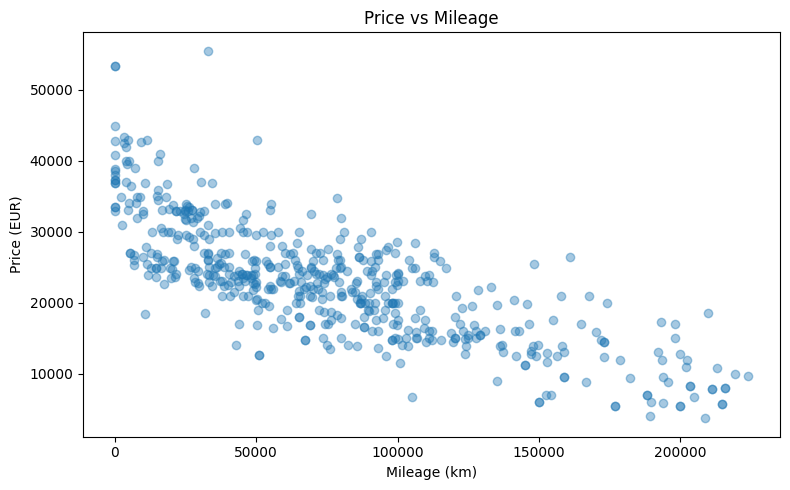

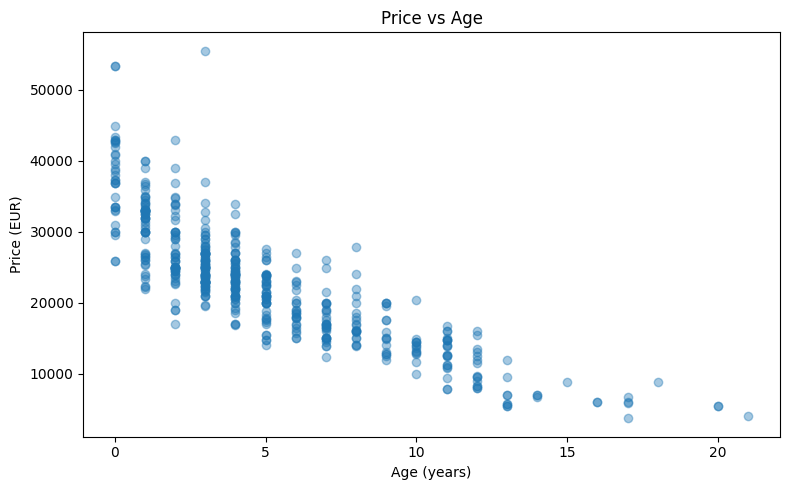

In [37]:
# Scatter: price vs mileage (sample for speed)
PLOT_MAX_POINTS = 20000
plot_df = df.sample(n=min(PLOT_MAX_POINTS, len(df)), random_state=RANDOM_SEED)

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["mileage_km"], plot_df["price_eur"], alpha=0.4)
plt.xlabel("Mileage (km)")
plt.ylabel("Price (EUR)")
plt.title("Price vs Mileage")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "scatter_price_vs_mileage.png", dpi=150)
plt.show()

# Scatter: price vs age
plt.figure(figsize=(8, 5))
plt.scatter(plot_df["age_years"], plot_df["price_eur"], alpha=0.4)
plt.xlabel("Age (years)")
plt.ylabel("Price (EUR)")
plt.title("Price vs Age")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "scatter_price_vs_age.png", dpi=150)
plt.show()


## Step 5 - Train/test split and baseline checks

We split the data so we can evaluate model performance on unseen examples.


In [38]:
# Features and target for modeling
X_mileage = df[["mileage_km"]]
X_age = df[["age_years"]]
X_both = df[["mileage_km", "age_years"]]
y = df["price_eur"]

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_both, y, test_size=0.2, random_state=RANDOM_SEED
)

print("Train size:", Xb_train.shape[0])
print("Test size:", Xb_test.shape[0])
print("Price summary (EUR):")
print(y.describe())


Train size: 419
Test size: 105
Price summary (EUR):
count           524.0
mean     23022.387405
std       8253.424608
min            3699.0
25%           16990.0
50%           22999.0
75%           26960.0
max           55500.0
Name: price_eur, dtype: Float64


## Step 6 - Univariate regression: price ~ mileage

Univariate regression uses a single predictor. Here the coefficient is the expected change in price (EUR) for one additional kilometer of mileage.


In [39]:
# Fit and evaluate the model
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_mileage, y, test_size=0.2, random_state=RANDOM_SEED
)

model_mileage = LinearRegression()
model_mileage.fit(Xm_train, ym_train)

# Predictions
ym_pred_train = model_mileage.predict(Xm_train)
ym_pred_test = model_mileage.predict(Xm_test)

# Metrics
r2_train = r2_score(ym_train, ym_pred_train)
r2_test = r2_score(ym_test, ym_pred_test)
mae = mean_absolute_error(ym_test, ym_pred_test)
rmse = mean_squared_error(ym_test, ym_pred_test) ** 0.5

print("Intercept (EUR):", model_mileage.intercept_)
print("Coefficient (EUR per km):", model_mileage.coef_[0])
print("R2 train:", r2_train)
print("R2 test:", r2_test)
print("MAE test (EUR):", mae)
print("RMSE test (EUR):", rmse)



Intercept (EUR): 32106.042812490356
Coefficient (EUR per km): -0.119677049291075
R2 train: 0.6211577429433909
R2 test: 0.5669600653036666
MAE test (EUR): 4247.630522603833
RMSE test (EUR): 5468.09507037834


## Step 7 - Univariate regression: price ~ age

Here the coefficient is the expected change in price (EUR) for one additional year of age.


In [40]:
# Fit and evaluate the model
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_age, y, test_size=0.2, random_state=RANDOM_SEED
)

model_age = LinearRegression()
model_age.fit(Xa_train, ya_train)

# Predictions
ya_pred_train = model_age.predict(Xa_train)
ya_pred_test = model_age.predict(Xa_test)

# Metrics
r2_train = r2_score(ya_train, ya_pred_train)
r2_test = r2_score(ya_test, ya_pred_test)
mae = mean_absolute_error(ya_test, ya_pred_test)
rmse = mean_squared_error(ya_test, ya_pred_test) ** 0.5

print("Intercept (EUR):", model_age.intercept_)
print("Coefficient (EUR per year):", model_age.coef_[0])
print("R2 train:", r2_train)
print("R2 test:", r2_test)
print("MAE test (EUR):", mae)
print("RMSE test (EUR):", rmse)



Intercept (EUR): 31637.561785281952
Coefficient (EUR per year): -1785.069239977051
R2 train: 0.7141443908077588
R2 test: 0.680394812569725
MAE test (EUR): 3371.8016934026837
RMSE test (EUR): 4697.631999860571


## Step 8 - Multivariate regression: price ~ mileage + age

Multivariate regression includes multiple predictors. Each coefficient shows the expected change in price while holding the other variable constant.


In [41]:
# Fit and evaluate the model
model_both = LinearRegression()
model_both.fit(Xb_train, y_train)

# Predictions
yb_pred_train = model_both.predict(Xb_train)
yb_pred_test = model_both.predict(Xb_test)

# Metrics
r2_train = r2_score(y_train, yb_pred_train)
r2_test = r2_score(y_test, yb_pred_test)
mae = mean_absolute_error(y_test, yb_pred_test)
rmse = mean_squared_error(y_test, yb_pred_test) ** 0.5

print("Intercept (EUR):", model_both.intercept_)
print("Coefficient mileage (EUR per km):", model_both.coef_[0])
print("Coefficient age (EUR per year):", model_both.coef_[1])
print("R2 train:", r2_train)
print("R2 test:", r2_test)
print("MAE test (EUR):", mae)
print("RMSE test (EUR):", rmse)



Intercept (EUR): 32896.192180612
Coefficient mileage (EUR per km): -0.05140459940918517
Coefficient age (EUR per year): -1235.3026261592834
R2 train: 0.7610062190496236
R2 test: 0.73187397019595
MAE test (EUR): 3089.7918987018766
RMSE test (EUR): 4302.705000354075


## Step 9 - Compare models and interpret results

Univariate models show the raw relationship with price. The multivariate model adjusts each coefficient for the other variable.

R^2 shows the proportion of variance explained (higher is better). MAE and RMSE are error metrics in EUR; lower is better. RMSE penalizes large errors more than MAE.


In [42]:
# Compare models on the same test split
# Build a small comparison table
metrics = []

# Univariate mileage
ym_pred_test = model_mileage.predict(Xm_test)
metrics.append({
    "model": "price ~ mileage",
    "r2_test": r2_score(ym_test, ym_pred_test),
    "mae_test": mean_absolute_error(ym_test, ym_pred_test),
    "rmse_test": mean_squared_error(ym_test, ym_pred_test) ** 0.5,
})

# Univariate age
ya_pred_test = model_age.predict(Xa_test)
metrics.append({
    "model": "price ~ age",
    "r2_test": r2_score(ya_test, ya_pred_test),
    "mae_test": mean_absolute_error(ya_test, ya_pred_test),
    "rmse_test": mean_squared_error(ya_test, ya_pred_test) ** 0.5,
})

# Multivariate
yb_pred_test = model_both.predict(Xb_test)
metrics.append({
    "model": "price ~ mileage + age",
    "r2_test": r2_score(y_test, yb_pred_test),
    "mae_test": mean_absolute_error(y_test, yb_pred_test),
    "rmse_test": mean_squared_error(y_test, yb_pred_test) ** 0.5,
})

metrics_df = pd.DataFrame(metrics)
print(metrics_df)


                   model   r2_test     mae_test   rmse_test
0        price ~ mileage  0.566960  4247.630523  5468.09507
1            price ~ age  0.680395  3371.801693  4697.63200
2  price ~ mileage + age  0.731874  3089.791899  4302.70500


## Step 10 - Prediction intervals and "bargain" labeling

Confidence intervals describe uncertainty in the mean prediction. Prediction intervals are wider because they describe where a *new observation* is likely to fall.

We label a listing as a bargain when its observed price is below the lower bound of the prediction interval. This is an operational definition based on our model, not a ground truth.


Bargain cars: 28


,listing_id,price_eur,mileage_km,age_years,make,model,predicted_price_eur,pi_lower_eur,pi_upper_eur,bargain
8,610,25490,11347.0,1.0,audi,a3,31269.039243,26009.012080,36529.066406,1
28,345,16920,99623.0,4.0,audi,a3,22893.762296,17636.536805,28150.987787,1
48,613,25890,20800.0,0.0,audi,a3,32033.664115,26773.028884,37294.299346,1
76,477,13999,137000.0,5.0,audi,a3,19687.399771,14420.107118,24954.692424,1
77,586,22315,43774.0,1.0,audi,a3,29578.280608,24320.387470,34836.173746,1
87,616,25990,6714.0,1.0,audi,a3,31510.605986,26249.557320,36771.654651,1
98,600,23990,21600.0,1.0,audi,a3,30734.443126,25476.039911,35992.846341,1
103,491,18990,50765.0,4.0,audi,a3,25441.240798,20187.356308,30695.125289,1
207,225,17660,58751.0,5.0,audi,a3,23767.338478,18513.333672,29021.343283,1
213,489,18450,10504.0,6.0,audi,a3,25025.450538,19747.411600,30303.489476,1


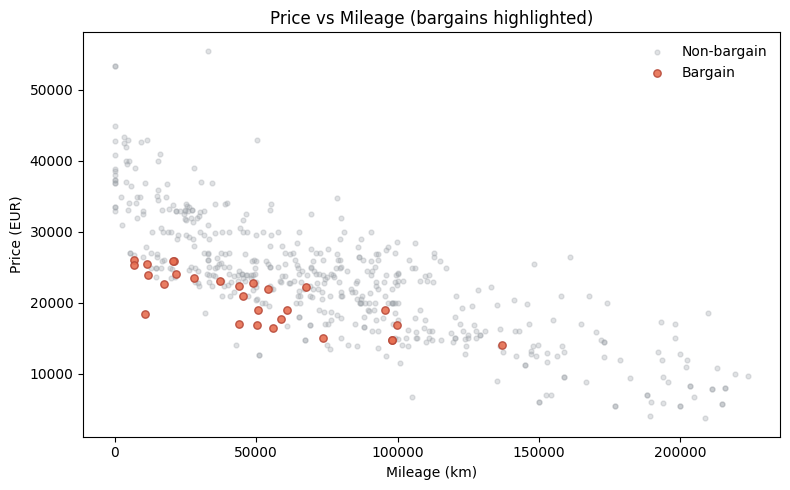

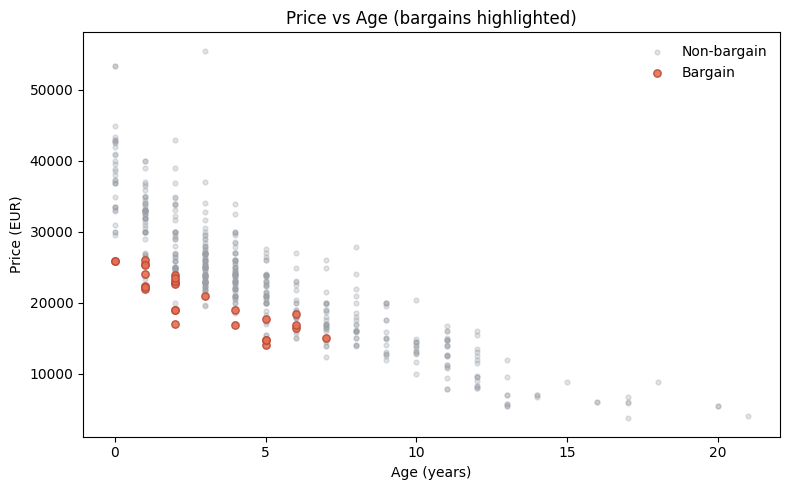

   listing_id  price_eur  mileage_km  age_years  make model  \
0         199      20480     50300.0        5.0  audi    a3   
1         236      23630     14712.0        3.0  audi    a3   
2         318      24950     64920.0        4.0  audi    a3   
3         447      33900     25217.0        1.0  audi    a3   
4         452      36900       100.0        0.0  audi    a3   

   predicted_price_eur  pi_lower_eur  pi_upper_eur  bargain  bargain_score  
0         24207.977489  18952.347653  29463.607325        0       0.153998  
1         28578.569357  23317.569427  33839.569287        0       0.173157  
2         24703.192614  19450.393004  29955.992224        0            0.0  
3         30545.851089  25287.811371  35803.890808        0            0.0  
4         33112.971598  27849.836788  38376.106408        0            0.0  
bargain
0    496
1     28
Name: count, dtype: int64


In [43]:
# Fit a final multivariate model on full data for labeling
model_full = LinearRegression()
model_full.fit(X_both, y)

# Baseline predictions
predicted_price = model_full.predict(X_both)

Xb_sm_full = sm.add_constant(X_both)
ols_full = sm.OLS(y, Xb_sm_full).fit()
pred_frame = ols_full.get_prediction(Xb_sm_full).summary_frame(alpha=0.20)
# 80% prediction interval (wider intervals use larger alpha)
pi_lower = pred_frame["obs_ci_lower"].values
pi_upper = pred_frame["obs_ci_upper"].values

# Build labeled DataFrame
final_df = df.copy()

final_df["predicted_price_eur"] = predicted_price
final_df["pi_lower_eur"] = pi_lower
final_df["pi_upper_eur"] = pi_upper

final_df["bargain"] = (final_df["price_eur"] < final_df["pi_lower_eur"]).astype(int)
# Bargain rule: price is below the lower prediction interval

# List bargain cars
bargains = final_df[final_df["bargain"] == 1]
print('Bargain cars:', len(bargains))
display(bargains)

# Save bargain-highlighted scatterplots
plot_bargain_scatters(final_df, REPORTS_DIR)
final_df["bargain_score"] = (
    (final_df["predicted_price_eur"] - final_df["price_eur"])
    / final_df["predicted_price_eur"]
).clip(0, 1)

print(final_df.head())
print(final_df["bargain"].value_counts())


## Step 11 - Export labeled dataset for Session 7

We save the labeled dataset for logistic regression in Session 7.


In [44]:
csv_path = DATA_PROCESSED_DIR / "session6_labeled_bargains.csv"

final_df.to_csv(csv_path, index=False)
print("Saved CSV to:", csv_path)



Saved CSV to: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\data\processed\session6_labeled_bargains.csv


## Step 12 - Save bargains to BigQuery
We overwrite the `fact_bargains` table with the current results. This avoids inserts and keeps only the listings analyzed in this notebook.


In [45]:
# Overwrite the BigQuery table with current results
# Step 12 - Write bargains back to BigQuery (replace table)
bargains_table = f"{project_id}.{dataset_id}.fact_bargains"

bargains_df = final_df[["listing_id", "bargain"]].copy()
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE"
)
client.load_table_from_dataframe(bargains_df, bargains_table, job_config=job_config).result()
print("Bargains table replaced.")


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Bargains table replaced.


## Step 12 - Summary and next steps

We scoped the data to a single make/model, fit univariate and multivariate regressions, and labeled potential bargains using prediction intervals.

### What you should reuse next session

- The labeled dataset with the `bargain` target column.
- The same feature columns (`mileage_km`, `age_years`) and scope filters.
- The operational definition of bargains, remembering it depends on the model baseline.
